<a href="https://colab.research.google.com/github/JossGonzalezHD/airbnb-cdmx-worldcup2026/blob/main/airbnb_cdmx_worldcup2026_v2_comparative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏟️ Airbnb CDMX: Pricing Intelligence for the 2026 World Cup
## A Comparative Machine Learning Study: Random Forest vs Neural Network

---

**Author:** Joseph Gonzalez  
**Date:** March 2026  
**Course:** Machine Learning and Predictive Modeling — Universidad Tecmilenio  
**Dataset:** Inside Airbnb CDMX — September 27, 2025  
**Tool:** Python 3 / Google Colab / Scikit-learn  

---

### 🎯 Business Objective
NIDO operates short-term rental properties across **Miguel Hidalgo** (Polanco) and **Cuauhtémoc** (Condesa, Roma) in Mexico City.  
With the **2026 FIFA World Cup** arriving in June-July 2026, this analysis builds and compares two Machine Learning models to:
1. Predict nightly rental prices based on property characteristics
2. Identify pricing optimization opportunities for NIDO properties
3. Recommend the best model for real-world implementation

---

### 📋 Notebook Structure
| Section | Description |
|---------|-------------|
| 1. Setup & Data Loading | Libraries, Drive mount, dataset import |
| 2. Data Cleaning & Feature Engineering | Outlier removal, encoding, distance to Azteca |
| 3. Exploratory Data Analysis | Key visualizations and market insights |
| 4. Model 1 — Random Forest | Baseline model training and evaluation |
| 5. Model 2 — Neural Network | MLP Regressor training and evaluation |
| 6. Model Comparison | Side-by-side metrics and visualizations |
| 7. NIDO Business Insights | World Cup pricing strategy for Miguel Hidalgo & Cuauhtémoc |

## Section 1: Setup & Data Loading
> Importing libraries, mounting Google Drive, and loading the Airbnb CDMX dataset.

In [ ]:
# ─── 1.1 LIBRARIES ────────────────────────────────────────────────────────────
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Geospatial
from geopy.distance import geodesic

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Machine Learning - Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### 1.2 Data Loading
Loading the Airbnb CDMX dataset from Google Drive.  
**Source:** Inside Airbnb — insideairbnb.com/get-the-data  
**Snapshot date:** September 27, 2025  
**Raw records:** 27,052 properties | 76 columns

In [ ]:
# ─── 1.2 DATA LOADING ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Load dataset from Google Drive
PATH = '/content/drive/MyDrive/airbnb_cdmx_project/listings.csv'

df = pd.read_csv(PATH, low_memory=False)

# Select relevant columns
COLUMNS = [
    'id', 'neighbourhood_cleansed', 'latitude', 'longitude',
    'room_type', 'accommodates', 'bedrooms', 'bathrooms_text',
    'number_of_reviews', 'review_scores_rating', 'availability_365', 'price'
]

df = df[COLUMNS]

print(f"✅ Dataset loaded successfully")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

Mounted at /content/drive
✅ Dataset loaded successfully
   Rows: 27,051
   Columns: 12


## Section 2: Data Cleaning & Feature Engineering
> Handling nulls, removing outliers using IQR by category, encoding categorical variables,  
> and engineering the key feature: **distance to Estadio Azteca**.

In [ ]:
# ─── 2.1 INITIAL CLEANING ─────────────────────────────────────────────────────

# Drop rows where price is null (no target = no use)
df = df.dropna(subset=['price'])

# Clean price column: remove $ and commas, convert to float
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].astype(float)

# Impute missing bedrooms with median
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

# Filter relevant room types only
df = df[df['room_type'].isin(['Entire home/apt', 'Private room'])]

print(f"✅ Initial cleaning complete")
print(f"   Rows after cleaning: {len(df):,}")
print(f"   Price dtype: {df['price'].dtype}")
print(f"   Bedrooms nulls: {df['bedrooms'].isnull().sum()}")

✅ Initial cleaning complete
   Rows after cleaning: 23,256
   Price dtype: float64
   Bedrooms nulls: 0


### 2.2 Outlier Removal — IQR Method by Category
Applying IQR independently per room type, since Entire home/apt and Private room  
represent distinct market segments with different price dynamics.

In [ ]:
# ─── 2.2 OUTLIER REMOVAL (IQR BY ROOM TYPE) ───────────────────────────────────

def remove_outliers_iqr(data, column, group_col, group_val):
    """Remove outliers using IQR method for a specific group."""
    subset = data[data[group_col] == group_val]
    Q1 = subset[column].quantile(0.25)
    Q3 = subset[column].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    return lower, upper

# Calculate limits per room type
lower_entire, upper_entire = remove_outliers_iqr(df, 'price', 'room_type', 'Entire home/apt')
lower_private, upper_private = remove_outliers_iqr(df, 'price', 'room_type', 'Private room')

print(f"Entire home/apt → upper limit: ${upper_entire:,.0f} MXN")
print(f"Private room    → upper limit: ${upper_private:,.0f} MXN")

# Apply filters
cond1 = (df['room_type'] == 'Entire home/apt') & (df['price'] <= upper_entire)
cond2 = (df['room_type'] == 'Private room') & (df['price'] <= upper_private)
df_clean = df[cond1 | cond2].copy()

print(f"\n✅ Outlier removal complete")
print(f"   Rows before: {len(df):,}")
print(f"   Rows after:  {len(df_clean):,}")
print(f"   Removed:     {len(df) - len(df_clean):,} outliers ({(len(df)-len(df_clean))/len(df)*100:.1f}%)")

Entire home/apt → upper limit: $3,280 MXN
Private room    → upper limit: $1,599 MXN

✅ Outlier removal complete
   Rows before: 23,256
   Rows after:  21,192
   Removed:     2,064 outliers (8.9%)


### 2.3 Feature Engineering — Distance to Estadio Azteca
Creating a key variable: straight-line distance (km) from each property  
to Estadio Azteca using the **Haversine formula** via geopy.  
This variable captures proximity value during the 2026 World Cup.

In [ ]:
# ─── 2.3 FEATURE ENGINEERING: DISTANCE TO ESTADIO AZTECA ─────────────────────

AZTECA_COORDS = (19.3029, -99.1500)

def calc_distance(row):
    """Calculate geodesic distance in km from property to Estadio Azteca."""
    return geodesic((row['latitude'], row['longitude']), AZTECA_COORDS).km

df_clean['distance_to_azteca'] = df_clean.apply(calc_distance, axis=1)

print(f"✅ Distance feature created")
print(f"   Min distance: {df_clean['distance_to_azteca'].min():.2f} km")
print(f"   Max distance: {df_clean['distance_to_azteca'].max():.2f} km")
print(f"   Mean distance: {df_clean['distance_to_azteca'].mean():.2f} km")

✅ Distance feature created
   Min distance: 0.31 km
   Max distance: 26.83 km
   Mean distance: 12.39 km


### 2.4 Encoding & Model Dataset Preparation
Applying One Hot Encoding to categorical variables and preparing  
the final dataset for both models.

In [ ]:
# ─── 2.4 ENCODING & FINAL DATASET ─────────────────────────────────────────────

# Select features
FEATURES = [
    'accommodates', 'bedrooms', 'number_of_reviews',
    'review_scores_rating', 'availability_365',
    'distance_to_azteca', 'room_type', 'neighbourhood_cleansed'
]

df_model = df_clean[FEATURES + ['price']].copy()

# Drop remaining nulls
df_model = df_model.dropna()

# One Hot Encoding
df_model = pd.get_dummies(df_model,
                          columns=['room_type', 'neighbourhood_cleansed'],
                          drop_first=True)

print(f"✅ Dataset ready for modeling")
print(f"   Rows: {len(df_model):,}")
print(f"   Features: {df_model.shape[1] - 1}")
print(f"   Target: price")

✅ Dataset ready for modeling
   Rows: 19,249
   Features: 22
   Target: price


### 2.5 Train/Test Split & Feature Scaling
Splitting dataset 80/20 and applying StandardScaler.  
> ⚠️ Scaling is critical for the Neural Network — features on different scales  
> can cause the model to learn incorrectly. Random Forest does not require scaling  
> but we apply it to both for a fair comparison.

In [ ]:
# ─── 2.5 TRAIN/TEST SPLIT & SCALING ──────────────────────────────────────────

# Separate features and target
X = df_model.drop(columns=['price'])
y = df_model['price']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Split and scaling complete")
print(f"   Training rows: {X_train.shape[0]:,}")
print(f"   Testing rows:  {X_test.shape[0]:,}")
print(f"   Features:      {X_train.shape[1]}")

✅ Split and scaling complete
   Training rows: 15,399
   Testing rows:  3,850
   Features:      22


## Section 3: Exploratory Data Analysis
> Key market insights that contextualize the pricing opportunity for NIDO  
> during the 2026 FIFA World Cup in Mexico City.

/tmp/ipykernel_341/981631782.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='room_type', y='price', ax=axes[1],


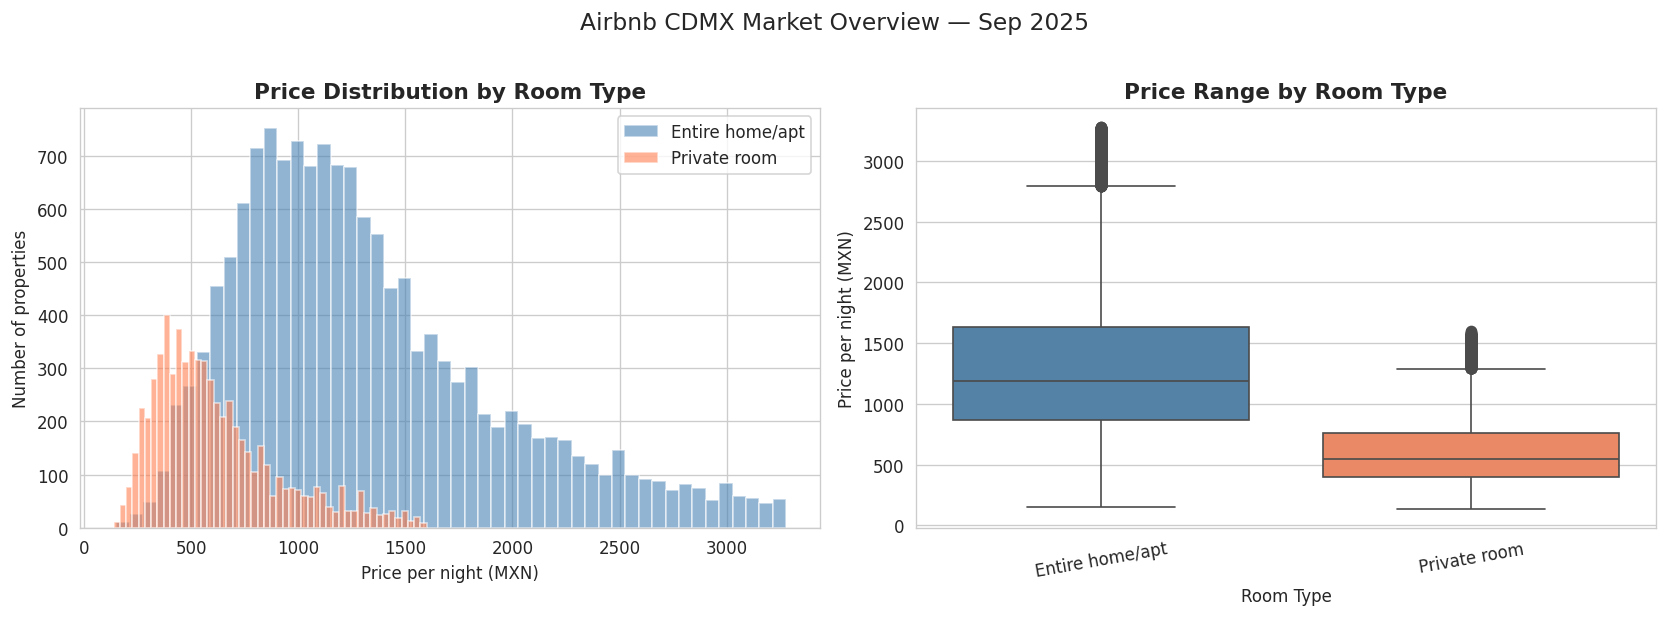

✅ Saved: viz_01_price_distribution.png


In [ ]:
# ─── 3.1 PRICE DISTRIBUTION BY ROOM TYPE ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram
for room, color in [('Entire home/apt', 'steelblue'), ('Private room', 'coral')]:
    subset = df_clean[df_clean['room_type'] == room]['price']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=room)

axes[0].set_title('Price Distribution by Room Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price per night (MXN)')
axes[0].set_ylabel('Number of properties')
axes[0].legend()

# Right: boxplot
sns.boxplot(data=df_clean, x='room_type', y='price', ax=axes[1],
            palette=['steelblue', 'coral'])
axes[1].set_title('Price Range by Room Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price per night (MXN)')
axes[1].tick_params(axis='x', rotation=10)

plt.suptitle('Airbnb CDMX Market Overview — Sep 2025', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_01_price_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_01_price_distribution.png")

### 3.2 Top Neighbourhoods by Average Price
> Identifying which delegations command premium prices  
> and where NIDO's core zones (Miguel Hidalgo & Cuauhtémoc) stand in the market.

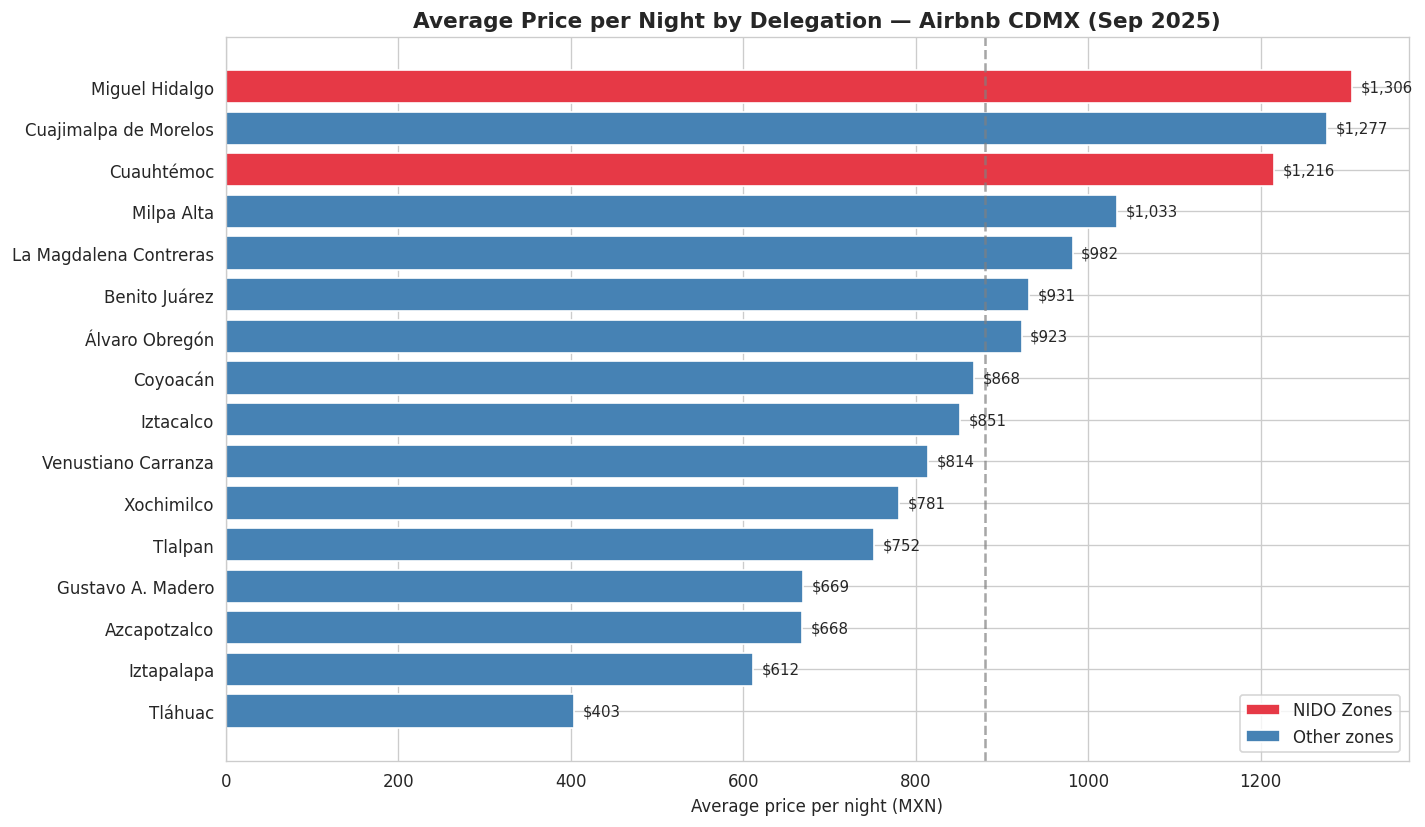

✅ Saved: viz_02_neighbourhoods.png


In [ ]:
# ─── 3.2 TOP NEIGHBOURHOODS BY AVERAGE PRICE ──────────────────────────────────

avg_price = (df_clean.groupby('neighbourhood_cleansed')['price']
             .mean()
             .sort_values(ascending=True))

# Define NIDO zones
nido_zones = ['Miguel Hidalgo', 'Cuauhtémoc']

# Color bars: highlight NIDO zones
colors = ['#E63946' if zone in nido_zones else 'steelblue'
          for zone in avg_price.index]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(avg_price.index, avg_price.values, color=colors)

# Add value labels
for bar, val in zip(bars, avg_price.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E63946', label='NIDO Zones'),
                   Patch(facecolor='steelblue', label='Other zones')]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_title('Average Price per Night by Delegation — Airbnb CDMX (Sep 2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average price per night (MXN)')
ax.set_ylabel('')
ax.axvline(x=avg_price.mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Market average: ${avg_price.mean():,.0f}')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_02_neighbourhoods.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_02_neighbourhoods.png")

### 3.3 Geographic Price Map — NIDO Zones Highlighted
> Visualizing the spatial distribution of prices across CDMX,  
> with NIDO's operating zones and Estadio Azteca marked for context.

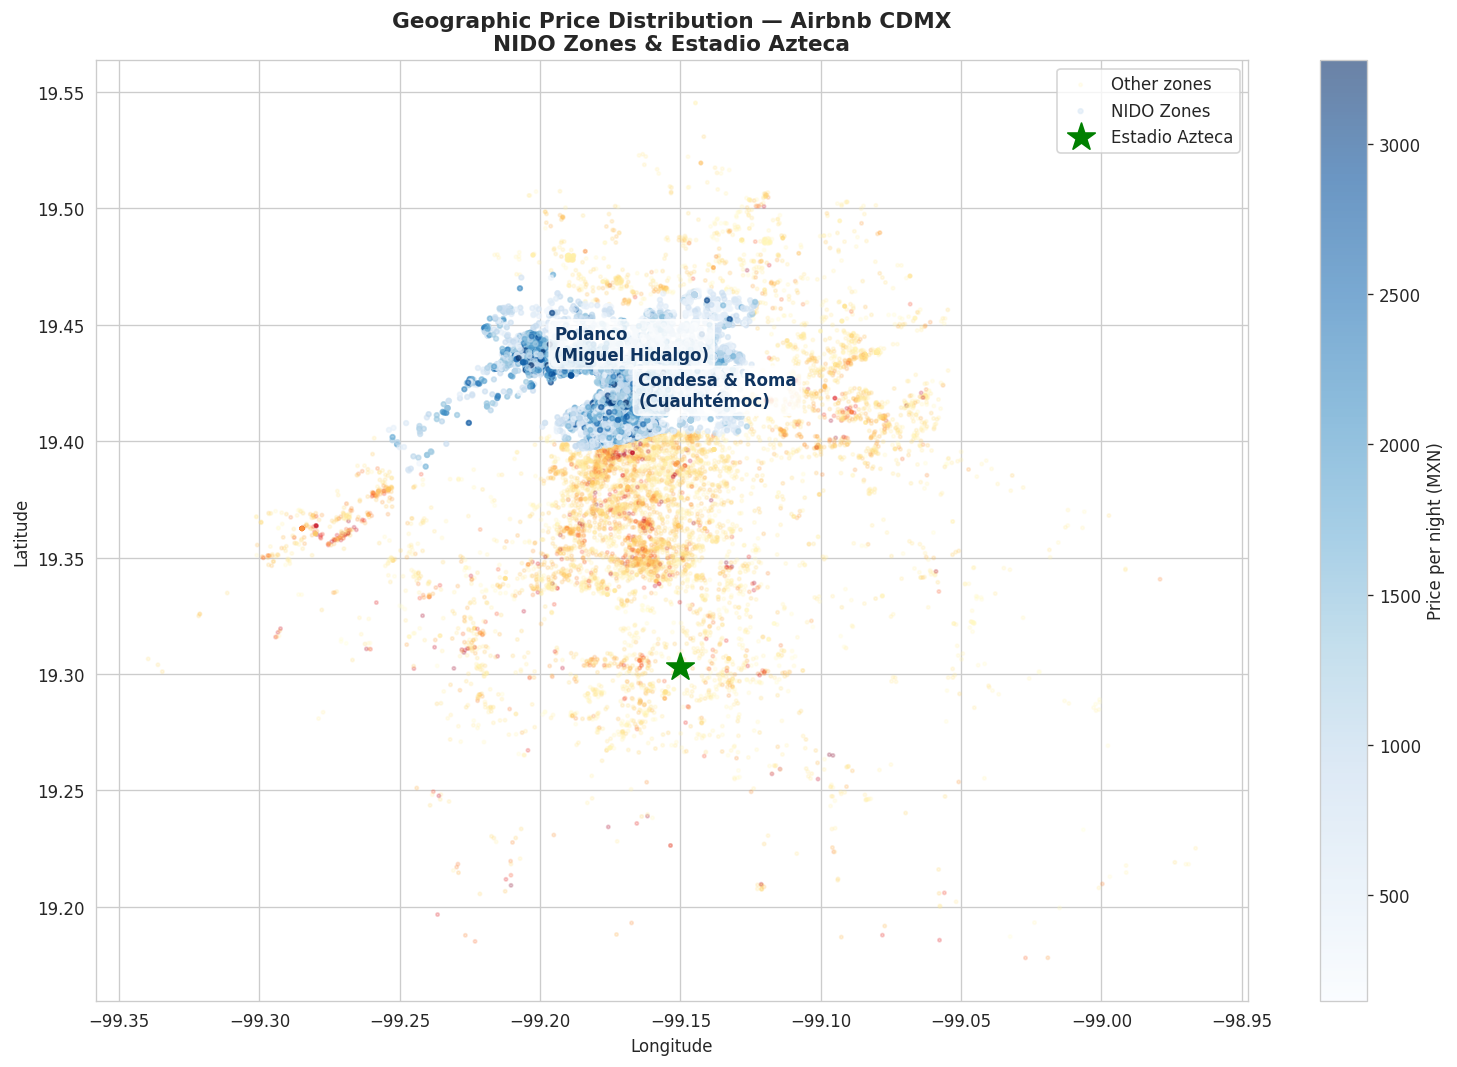

✅ Saved: viz_03_geo_map.png


In [ ]:
# ─── 3.3 GEOGRAPHIC PRICE MAP ─────────────────────────────────────────────────

# Filter NIDO zones
df_nido = df_clean[df_clean['neighbourhood_cleansed'].isin(nido_zones)]
df_other = df_clean[~df_clean['neighbourhood_cleansed'].isin(nido_zones)]

fig, ax = plt.subplots(figsize=(13, 9))

# Plot other zones
ax.scatter(df_other['longitude'], df_other['latitude'],
           c=df_other['price'], cmap='YlOrRd',
           alpha=0.2, s=4, label='Other zones')

# Plot NIDO zones highlighted
scatter_nido = ax.scatter(df_nido['longitude'], df_nido['latitude'],
                          c=df_nido['price'], cmap='Blues',
                          alpha=0.6, s=8, label='NIDO Zones')

# Estadio Azteca
ax.scatter(-99.1500, 19.3029, color='green', s=300,
           marker='*', zorder=5, label='Estadio Azteca')

# NIDO zone labels
ax.annotate('Polanco\n(Miguel Hidalgo)', xy=(-99.195, 19.435),
            fontsize=10, fontweight='bold', color='#0f3460',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.annotate('Condesa & Roma\n(Cuauhtémoc)', xy=(-99.165, 19.415),
            fontsize=10, fontweight='bold', color='#0f3460',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.colorbar(scatter_nido, ax=ax, label='Price per night (MXN)')
ax.set_title('Geographic Price Distribution — Airbnb CDMX\nNIDO Zones & Estadio Azteca',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_03_geo_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_03_geo_map.png")

## Section 4: Model 1 — Random Forest Regressor
> Baseline model trained on the full CDMX dataset.  
> Random Forest builds multiple decision trees and averages their predictions,  
> making it robust to outliers and capable of capturing non-linear relationships.

In [ ]:
# ─── 4.1 TRAIN RANDOM FOREST ──────────────────────────────────────────────────

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Use all CPU cores for faster training
)

rf_model.fit(X_train_scaled, y_train)

# Predictions
rf_pred = rf_model.predict(X_test_scaled)

# Metrics
rf_r2   = r2_score(y_test, rf_pred)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("=" * 45)
print("   MODEL 1: Random Forest Regressor")
print("=" * 45)
print(f"   R²   : {rf_r2:.4f}")
print(f"   MAE  : ${rf_mae:,.2f} MXN")
print(f"   RMSE : ${rf_rmse:,.2f} MXN")
print("=" * 45)
print(f"\n📊 The model explains {rf_r2*100:.1f}% of price variability")
print(f"📊 Average prediction error: ${rf_mae:,.0f} MXN per night")

   MODEL 1: Random Forest Regressor
   R²   : 0.5468
   MAE  : $291.85 MXN
   RMSE : $412.77 MXN

📊 The model explains 54.7% of price variability
📊 Average prediction error: $292 MXN per night


### 4.2 Random Forest — Predictions vs Actual Prices
> Evaluating how well the model predicts prices across the price spectrum.  
> A perfect model would show all points on the diagonal red line.

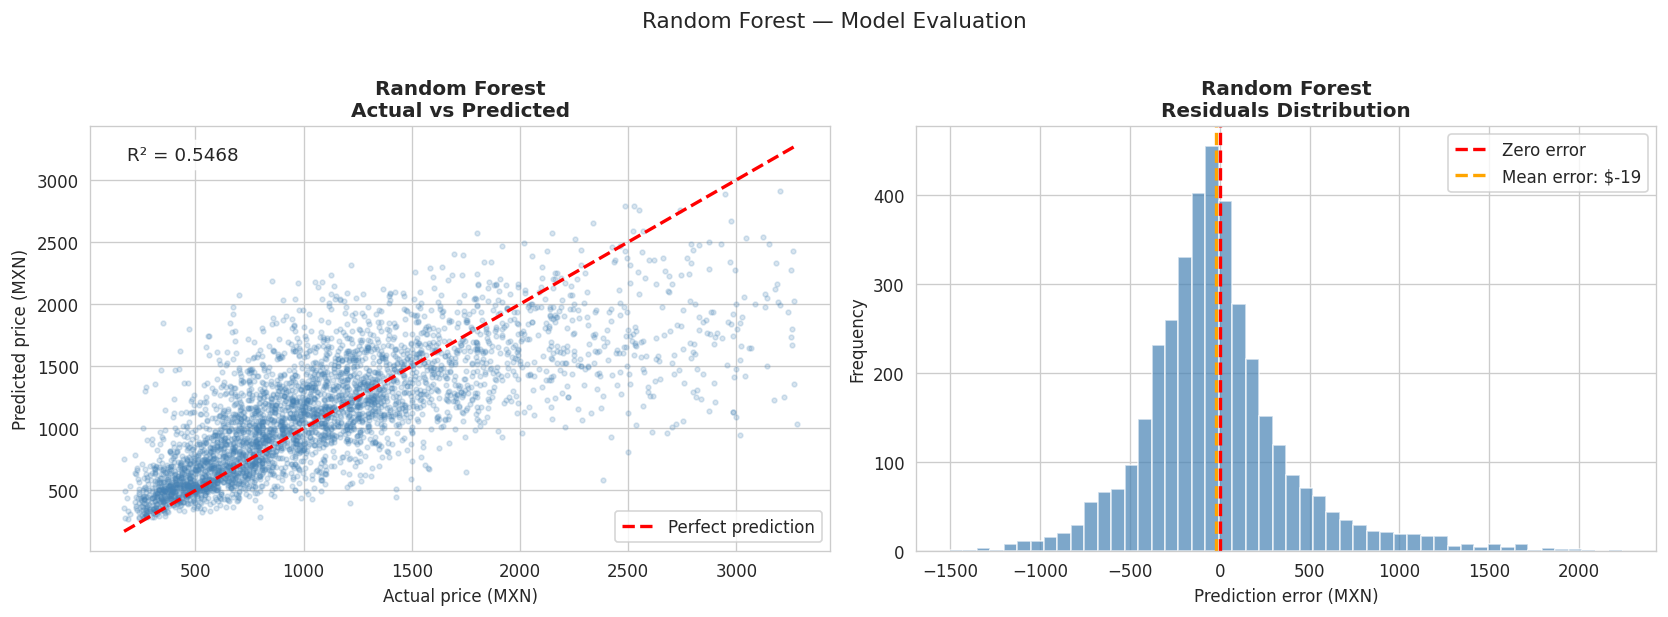

✅ Saved: viz_04_rf_evaluation.png


In [ ]:
# ─── 4.2 RANDOM FOREST: ACTUAL VS PREDICTED ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Predicted scatter
axes[0].scatter(y_test, rf_pred, alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Random Forest\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual price (MXN)')
axes[0].set_ylabel('Predicted price (MXN)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {rf_r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right: Residuals distribution
residuals_rf = y_test - rf_pred
axes[1].hist(residuals_rf, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(x=residuals_rf.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean error: ${residuals_rf.mean():,.0f}')
axes[1].set_title('Random Forest\nResiduals Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediction error (MXN)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Random Forest — Model Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_04_rf_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_04_rf_evaluation.png")

## Section 5: Model 2 — Neural Network (MLP Regressor)
> A Multi-Layer Perceptron (MLP) with one hidden layer is applied as the second model.  
> Unlike Random Forest which builds decision trees, a Neural Network learns by adjusting  
> internal weights through multiple passes over the data (epochs),  
> making it capable of capturing more complex price patterns.

In [ ]:
# ─── 5.1 TRAIN NEURAL NETWORK ─────────────────────────────────────────────────

nn_model = MLPRegressor(
    hidden_layer_sizes=(100,),   # One hidden layer with 100 neurons
    activation='relu',            # ReLU: standard activation for regression
    solver='adam',                # Adam: efficient optimizer
    max_iter=500,                 # Maximum training epochs
    random_state=42,
    early_stopping=True,          # Stop if no improvement
    validation_fraction=0.1,      # 10% of train for validation
    verbose=False
)

nn_model.fit(X_train_scaled, y_train)

# Predictions
nn_pred = nn_model.predict(X_test_scaled)

# Metrics
nn_r2   = r2_score(y_test, nn_pred)
nn_mae  = mean_absolute_error(y_test, nn_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))

print("=" * 45)
print("   MODEL 2: Neural Network (MLP Regressor)")
print("=" * 45)
print(f"   R²   : {nn_r2:.4f}")
print(f"   MAE  : ${nn_mae:,.2f} MXN")
print(f"   RMSE : ${nn_rmse:,.2f} MXN")
print("=" * 45)
print(f"\n📊 The model explains {nn_r2*100:.1f}% of price variability")
print(f"📊 Average prediction error: ${nn_mae:,.0f} MXN per night")
print(f"\n✅ Training completed in {nn_model.n_iter_} iterations")

   MODEL 2: Neural Network (MLP Regressor)
   R²   : 0.5106
   MAE  : $314.23 MXN
   RMSE : $428.92 MXN

📊 The model explains 51.1% of price variability
📊 Average prediction error: $314 MXN per night

✅ Training completed in 500 iterations


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### 5.2 Neural Network — Learning Curve & Predictions
> The learning curve shows how the model improved during training.  
> A healthy curve shows both train and validation loss decreasing and converging.

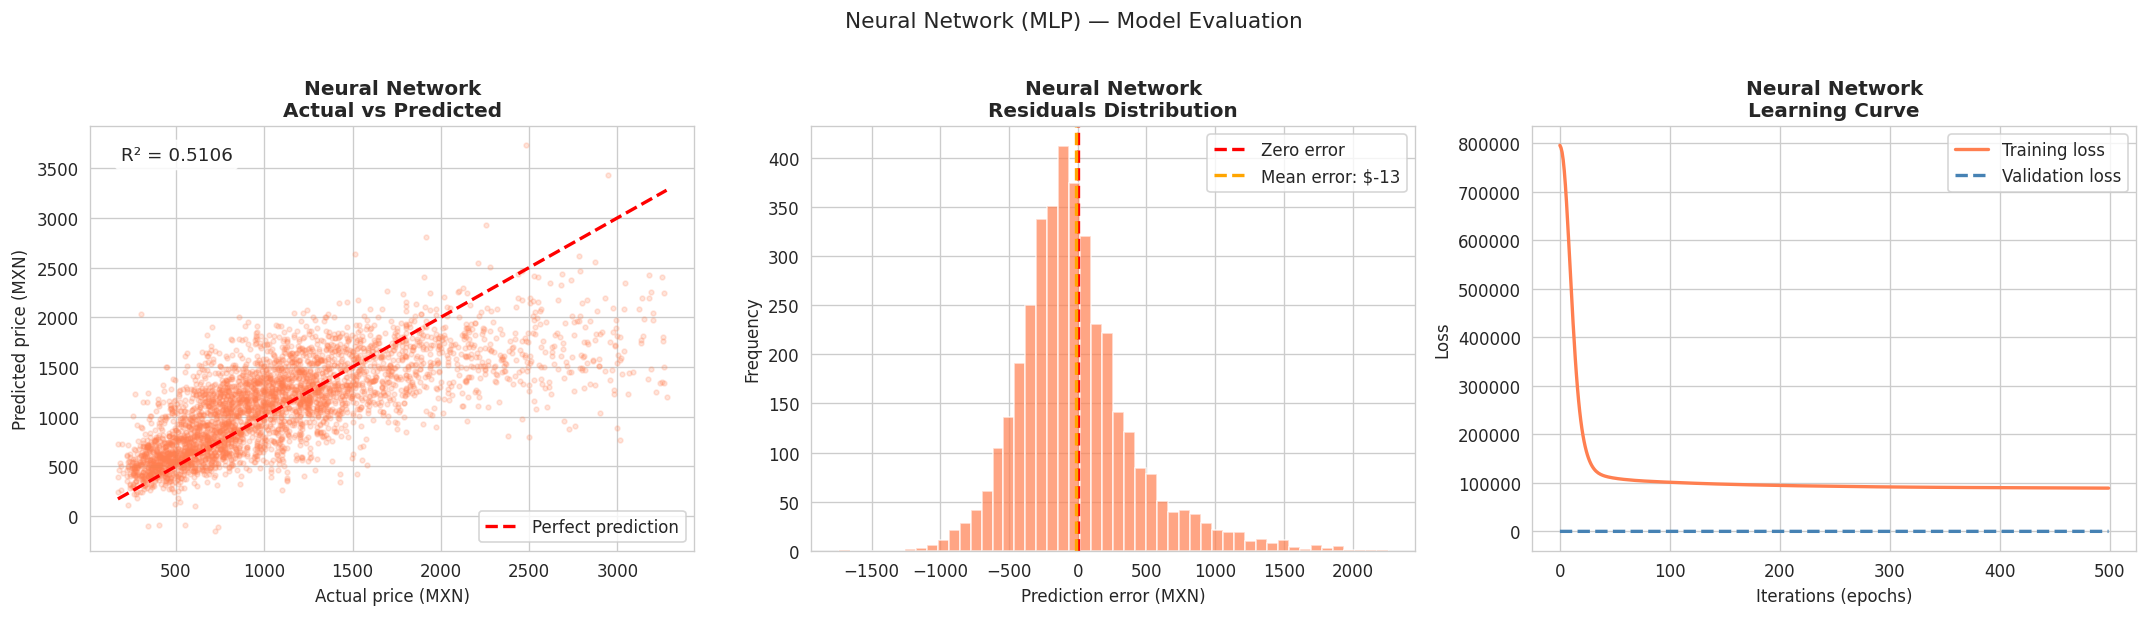

✅ Saved: viz_05_nn_evaluation.png
   Training stopped at iteration: 500


In [ ]:
# ─── 5.2 NEURAL NETWORK: EVALUATION PLOTS ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Actual vs Predicted
axes[0].scatter(y_test, nn_pred, alpha=0.2, s=8, color='coral')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Neural Network\nActual vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual price (MXN)')
axes[0].set_ylabel('Predicted price (MXN)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {nn_r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Middle: Residuals
residuals_nn = y_test - nn_pred
axes[1].hist(residuals_nn, bins=50, color='coral', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(x=residuals_nn.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean error: ${residuals_nn.mean():,.0f}')
axes[1].set_title('Neural Network\nResiduals Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Prediction error (MXN)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Right: Learning curve
axes[2].plot(nn_model.loss_curve_, color='coral', linewidth=2, label='Training loss')
if nn_model.validation_scores_ is not None:
    # Convert validation scores to loss for comparable scale
    axes[2].plot([1 - s for s in nn_model.validation_scores_],
                 color='steelblue', linewidth=2, linestyle='--', label='Validation loss')
axes[2].set_title('Neural Network\nLearning Curve', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Iterations (epochs)')
axes[2].set_ylabel('Loss')
axes[2].legend()

plt.suptitle('Neural Network (MLP) — Model Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_05_nn_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: viz_05_nn_evaluation.png")
print(f"   Training stopped at iteration: {nn_model.n_iter_}")

## Section 6: Model Comparison
> Side-by-side evaluation of Random Forest vs Neural Network.  
> Which model performs better for NIDO's pricing strategy?

In [ ]:
# ─── 6.1 METRICS COMPARISON TABLE ────────────────────────────────────────────

metrics = {
    'Metric': ['R²', 'MAE (MXN)', 'RMSE (MXN)'],
    'Random Forest': [f'{rf_r2:.4f}', f'${rf_mae:,.2f}', f'${rf_rmse:,.2f}'],
    'Neural Network': [f'{nn_r2:.4f}', f'${nn_mae:,.2f}', f'${nn_rmse:,.2f}'],
    'Winner': ['🏆 Random Forest', '🏆 Random Forest', '🏆 Random Forest']
}

df_metrics = pd.DataFrame(metrics)
print("=" * 60)
print("        MODEL COMPARISON — Random Forest vs Neural Network")
print("=" * 60)
print(df_metrics.to_string(index=False))
print("=" * 60)
print(f"\n📊 Random Forest explains {rf_r2*100:.1f}% of price variability")
print(f"📊 Neural Network explains {nn_r2*100:.1f}% of price variability")
print(f"\n📊 RF average error:  ${rf_mae:,.0f} MXN per night")
print(f"📊 NN average error:  ${nn_mae:,.0f} MXN per night")
print(f"\n📊 Difference in MAE: ${nn_mae - rf_mae:,.0f} MXN per night")

        MODEL COMPARISON — Random Forest vs Neural Network
    Metric Random Forest Neural Network          Winner
        R²        0.5468         0.5106 🏆 Random Forest
 MAE (MXN)       $291.85        $314.23 🏆 Random Forest
RMSE (MXN)       $412.77        $428.92 🏆 Random Forest

📊 Random Forest explains 54.7% of price variability
📊 Neural Network explains 51.1% of price variability

📊 RF average error:  $292 MXN per night
📊 NN average error:  $314 MXN per night

📊 Difference in MAE: $22 MXN per night


### 6.2 Visual Model Comparison
> Comparing both models across all metrics and prediction quality.  
> This is the key visualization for the executive recommendation.

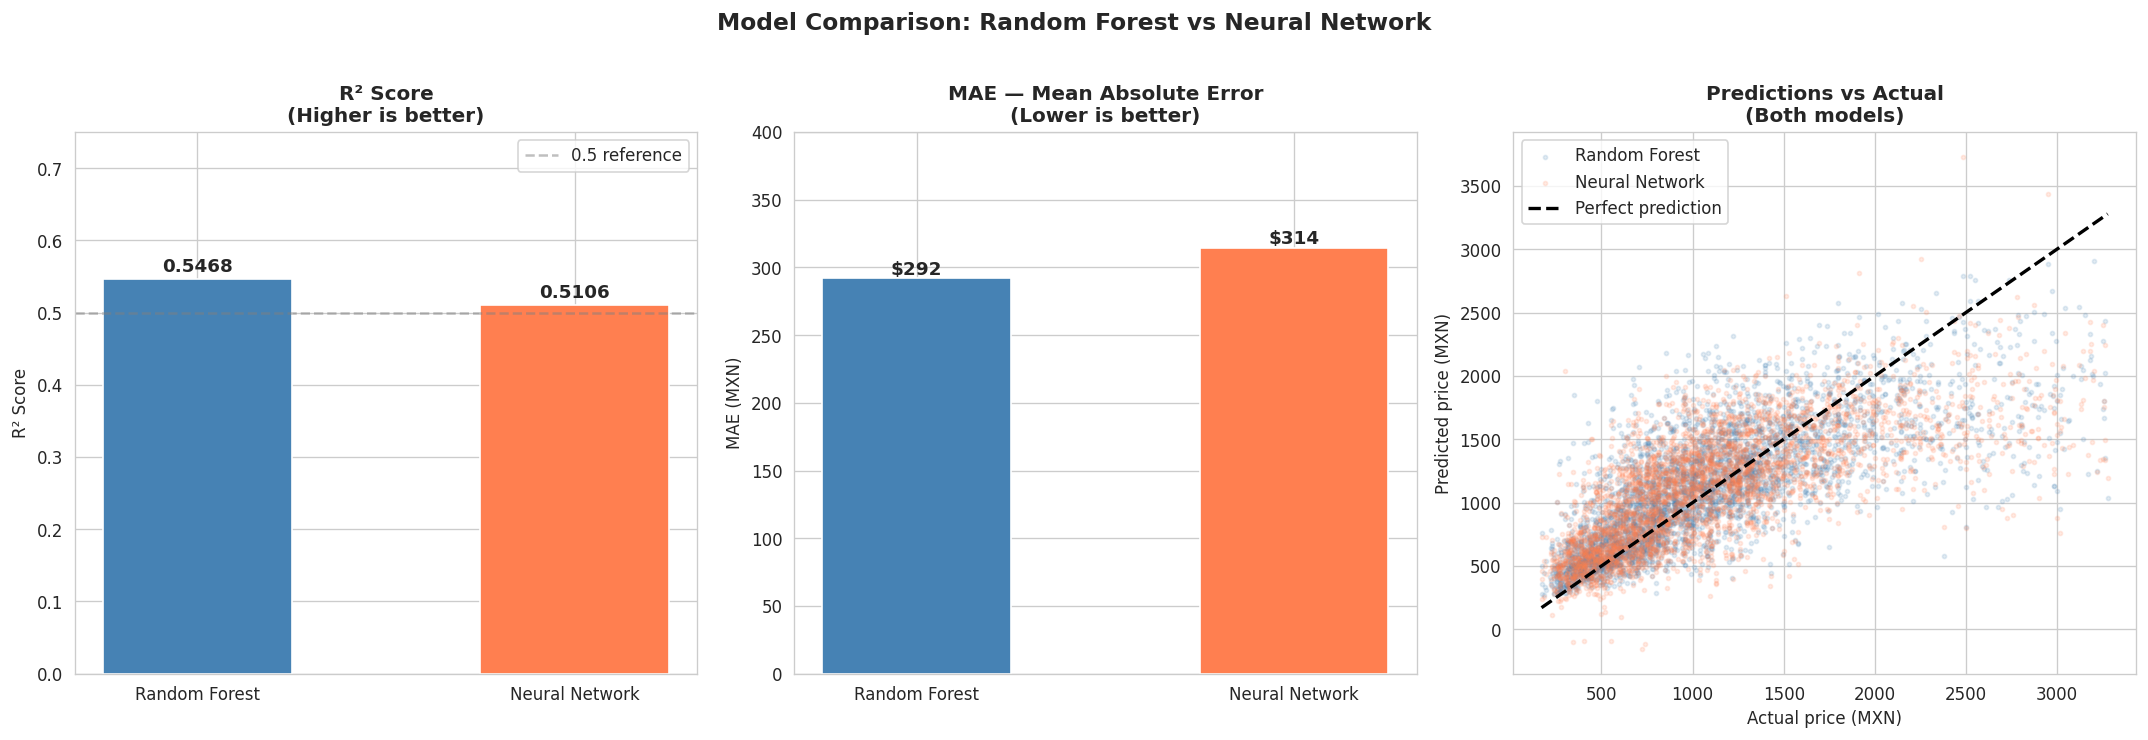

✅ Saved: viz_06_model_comparison.png


In [ ]:
# ─── 6.2 VISUAL MODEL COMPARISON ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Random Forest', 'Neural Network']
colors = ['steelblue', 'coral']

# Left: R² Comparison
r2_values = [rf_r2, nn_r2]
bars = axes[0].bar(models, r2_values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('R² Score\n(Higher is better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 0.75)
for bar, val in zip(bars, r2_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 reference')
axes[0].legend()

# Middle: MAE Comparison
mae_values = [rf_mae, nn_mae]
bars = axes[1].bar(models, mae_values, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('MAE — Mean Absolute Error\n(Lower is better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE (MXN)')
axes[1].set_ylim(0, 400)
for bar, val in zip(bars, mae_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 3,
                f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)

# Right: Predictions overlay
axes[2].scatter(y_test, rf_pred, alpha=0.15, s=6,
                color='steelblue', label='Random Forest')
axes[2].scatter(y_test, nn_pred, alpha=0.15, s=6,
                color='coral', label='Neural Network')
axes[2].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=2, label='Perfect prediction')
axes[2].set_title('Predictions vs Actual\n(Both models)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Actual price (MXN)')
axes[2].set_ylabel('Predicted price (MXN)')
axes[2].legend()

plt.suptitle('Model Comparison: Random Forest vs Neural Network',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_06_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_06_model_comparison.png")

## Section 7: NIDO Business Insights — World Cup 2026 Strategy
> Applying the winning model (Random Forest) to NIDO's specific market context.  
> Zones: Miguel Hidalgo (Polanco) & Cuauhtémoc (Condesa, Roma)  
> Event: FIFA World Cup 2026 — Mexico City matches: June-July 2026  
>
> **Assumptions based on operational knowledge:**
> - 100+ units per delegation (~210 total)
> - Unit mix: Studios (50%), 1BR (35%), 2BR (15%)
> - Current average occupancy: ~90%
> - Current average price range: $1,700–$3,060 MXN (USD 100–180)

In [ ]:
# ─── 7.1 NIDO MARKET ANALYSIS ─────────────────────────────────────────────────

# Filter NIDO zones from cleaned dataset
df_nido = df_clean[df_clean['neighbourhood_cleansed'].isin(nido_zones)].copy()

# Market statistics per zone
nido_stats = df_nido.groupby('neighbourhood_cleansed').agg(
    total_listings    = ('price', 'count'),
    avg_price         = ('price', 'mean'),
    median_price      = ('price', 'median'),
    avg_distance_km   = ('distance_to_azteca', 'mean'),
    avg_accommodates  = ('accommodates', 'mean'),
    avg_availability  = ('availability_365', 'mean')
).round(1)

print("=" * 65)
print("   NIDO OPERATING ZONES — Market Intelligence Report")
print("=" * 65)
print(nido_stats.to_string())
print("=" * 65)

# Market position
total_market = len(df_clean)
nido_market  = len(df_nido)
print(f"\n📍 NIDO zones represent {nido_market/total_market*100:.1f}% of total CDMX market")
print(f"📍 Total listings in NIDO zones: {nido_market:,}")
print(f"📍 Market average price CDMX: ${df_clean['price'].mean():,.0f} MXN")
print(f"📍 NIDO zones average price:  ${df_nido['price'].mean():,.0f} MXN")
print(f"📍 NIDO premium over market:  {((df_nido['price'].mean()/df_clean['price'].mean())-1)*100:.1f}%")

   NIDO OPERATING ZONES — Market Intelligence Report
                        total_listings  avg_price  median_price  avg_distance_km  avg_accommodates  avg_availability
neighbourhood_cleansed                                                                                              
Cuauhtémoc                        9930    1215.80       1110.00            13.40              3.20            248.50
Miguel Hidalgo                    3392    1306.50       1170.00            14.90              3.20            254.50

📍 NIDO zones represent 62.9% of total CDMX market
📍 Total listings in NIDO zones: 13,322
📍 Market average price CDMX: $1,100 MXN
📍 NIDO zones average price:  $1,239 MXN
📍 NIDO premium over market:  12.6%


### 7.2 World Cup 2026 — Revenue Opportunity Projection
> Estimating potential revenue uplift for NIDO properties during  
> FIFA World Cup 2026 matches in Mexico City (June-July 2026).  
> Based on market data, operational assumptions, and model predictions.

In [ ]:
# ─── 7.2 WORLD CUP REVENUE PROJECTION ────────────────────────────────────────

# ── NIDO Operational Assumptions ──────────────────────────────────────────────
NIDO_UNITS = {
    'Miguel Hidalgo': {'total': 105, 'studio': 53, '1br': 37, '2br': 15},
    'Cuauhtémoc':     {'total': 110, 'studio': 55, '1br': 38, '2br': 17},
}

BASE_PRICES = {
    'studio': 1400,
    '1br':    1900,
    '2br':    2800,
}

WC_NIGHTS         = 30
CURRENT_OCCUPANCY = 0.90
WC_OCCUPANCY      = 0.98
WC_PRICE_UPLIFT   = 0.35

# ── Revenue Calculation ────────────────────────────────────────────────────────
results = []

for zone, units in NIDO_UNITS.items():
    for unit_type, base_price in BASE_PRICES.items():
        n_units = units[unit_type]

        current_rev = n_units * base_price * WC_NIGHTS * CURRENT_OCCUPANCY
        wc_price    = base_price * (1 + WC_PRICE_UPLIFT)
        wc_rev      = n_units * wc_price * WC_NIGHTS * WC_OCCUPANCY
        uplift      = wc_rev - current_rev

        results.append({
            'Zone':        zone,
            'Unit Type':   unit_type.upper(),
            'Units':       n_units,
            'Base Price':  base_price,
            'WC Price':    wc_price,
            'Current Rev': current_rev,
            'WC Rev':      wc_rev,
            'Uplift':      uplift,
        })

df_revenue = pd.DataFrame(results)

# ── Totals ─────────────────────────────────────────────────────────────────────
total_current = df_revenue['Current Rev'].sum()
total_wc      = df_revenue['WC Rev'].sum()
total_uplift  = total_wc - total_current

# ── Print Table ────────────────────────────────────────────────────────────────
df_display = df_revenue.copy()
df_display['Base Price']  = df_display['Base Price'].apply(lambda x: f'${x:,}')
df_display['WC Price']    = df_display['WC Price'].apply(lambda x: f'${x:,.0f}')
df_display['Current Rev'] = df_display['Current Rev'].apply(lambda x: f'${x:,.0f}')
df_display['WC Rev']      = df_display['WC Rev'].apply(lambda x: f'${x:,.0f}')
df_display['Uplift']      = df_display['Uplift'].apply(lambda x: f'${x:,.0f}')

print("=" * 75)
print("   NIDO — World Cup 2026 Revenue Opportunity (30 peak nights)")
print("=" * 75)
print(df_display.to_string(index=False))
print("=" * 75)
print(f"\n💰 Current revenue (30 nights):      ${total_current:>12,.0f} MXN")
print(f"💰 WC projected revenue (30 nights): ${total_wc:>12,.0f} MXN")
print(f"\n🚀 Total uplift opportunity:         ${total_uplift:>12,.0f} MXN")
print(f"🚀 Uplift in USD (~17 MXN/USD):      ${total_uplift/17:>12,.0f} USD")
print(f"🚀 Uplift percentage:                 {total_uplift/total_current*100:>11.1f}%")

   NIDO — World Cup 2026 Revenue Opportunity (30 peak nights)
          Zone Unit Type  Units Base Price WC Price Current Rev     WC Rev   Uplift
Miguel Hidalgo    STUDIO     53     $1,400   $1,890  $2,003,400 $2,944,998 $941,598
Miguel Hidalgo       1BR     37     $1,900   $2,565  $1,898,100 $2,790,207 $892,107
Miguel Hidalgo       2BR     15     $2,800   $3,780  $1,134,000 $1,666,980 $532,980
    Cuauhtémoc    STUDIO     55     $1,400   $1,890  $2,079,000 $3,056,130 $977,130
    Cuauhtémoc       1BR     38     $1,900   $2,565  $1,949,400 $2,865,618 $916,218
    Cuauhtémoc       2BR     17     $2,800   $3,780  $1,285,200 $1,889,244 $604,044

💰 Current revenue (30 nights):      $  10,349,100 MXN
💰 WC projected revenue (30 nights): $  15,213,177 MXN

🚀 Total uplift opportunity:         $   4,864,077 MXN
🚀 Uplift in USD (~17 MXN/USD):      $     286,122 USD
🚀 Uplift percentage:                        47.0%


### 7.3 World Cup Revenue Opportunity — Visual Summary
> The business case for NIDO's World Cup 2026 pricing strategy  
> visualized for executive presentation.

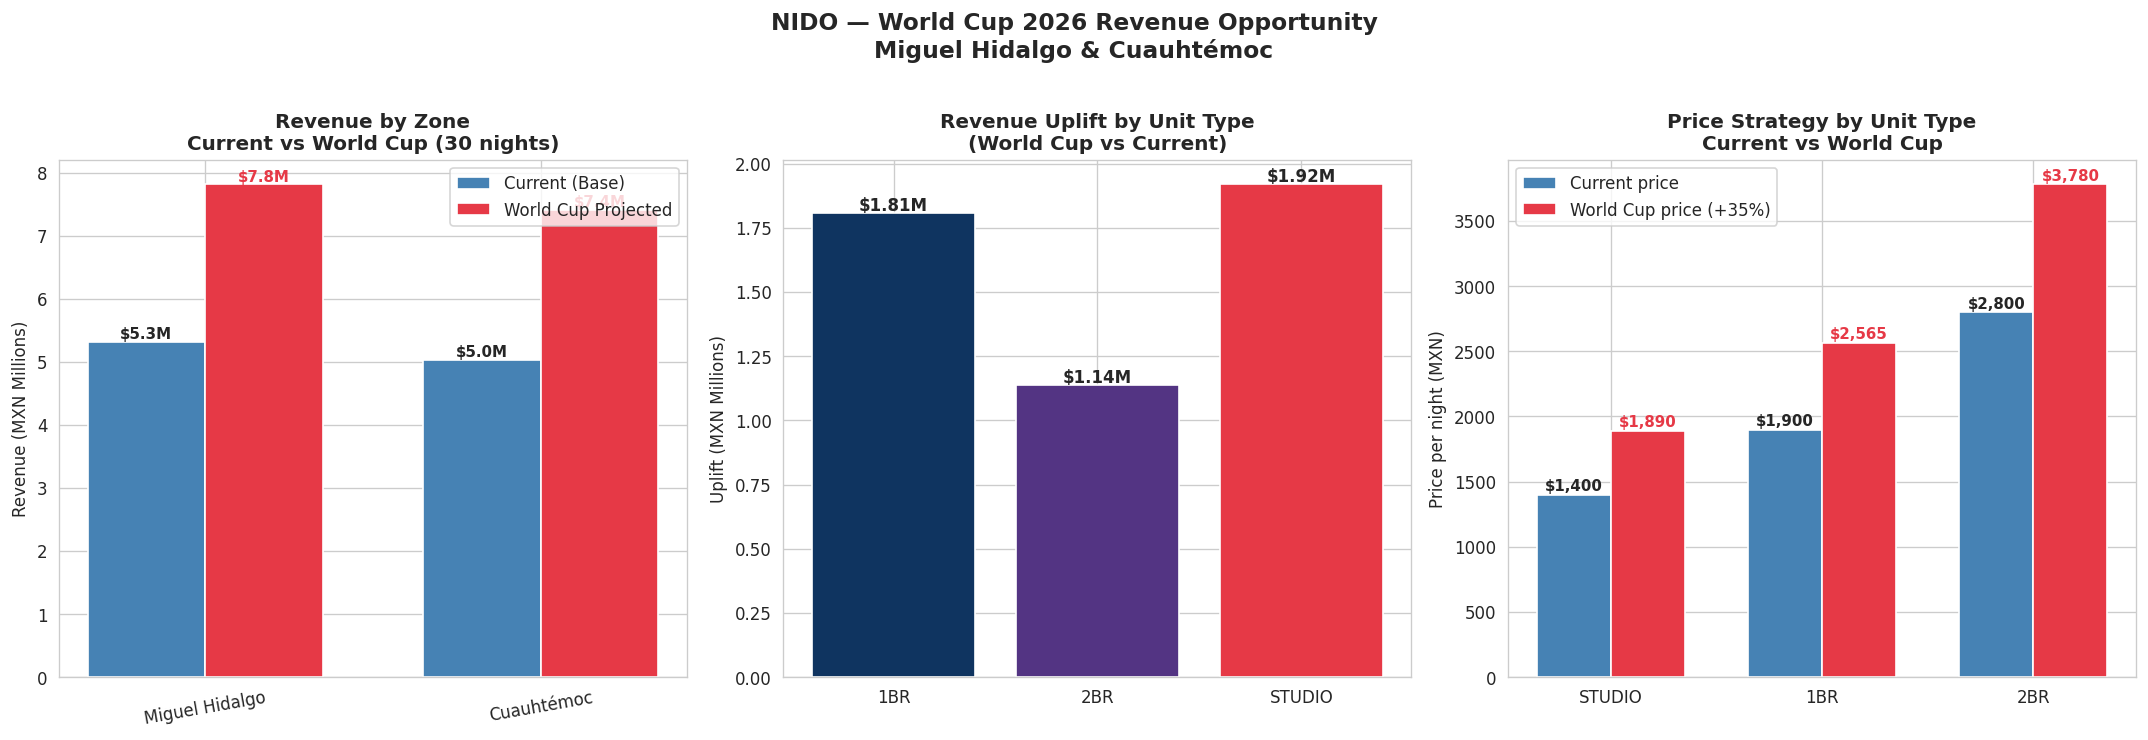

✅ Saved: viz_07_nido_revenue.png


In [ ]:
# ─── 7.3 REVENUE VISUALIZATION ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Left: Revenue comparison by zone ──────────────────────────────────────────
zones = ['Miguel Hidalgo', 'Cuauhtémoc']
current_by_zone = df_revenue.groupby('Zone')['Current Rev'].sum()
wc_by_zone      = df_revenue.groupby('Zone')['WC Rev'].sum()

x = np.arange(len(zones))
width = 0.35

axes[0].bar(x - width/2, current_by_zone.values/1e6, width,
            label='Current (Base)', color='steelblue', edgecolor='white')
axes[0].bar(x + width/2, wc_by_zone.values/1e6, width,
            label='World Cup Projected', color='#E63946', edgecolor='white')

axes[0].set_title('Revenue by Zone\nCurrent vs World Cup (30 nights)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue (MXN Millions)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(zones, rotation=10)
axes[0].legend()

for i, (cur, wc) in enumerate(zip(current_by_zone.values, wc_by_zone.values)):
    axes[0].text(i - width/2, cur/1e6 + 0.05, f'${cur/1e6:.1f}M',
                ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i + width/2, wc/1e6 + 0.05, f'${wc/1e6:.1f}M',
                ha='center', fontsize=9, fontweight='bold', color='#E63946')

# ── Middle: Uplift by unit type ───────────────────────────────────────────────
uplift_by_type = df_revenue.groupby('Unit Type')['Uplift'].sum()

colors_type = ['#0F3460', '#533483', '#E63946']
bars = axes[1].bar(uplift_by_type.index, uplift_by_type.values/1e6,
                   color=colors_type, edgecolor='white')
axes[1].set_title('Revenue Uplift by Unit Type\n(World Cup vs Current)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Uplift (MXN Millions)')

for bar, val in zip(bars, uplift_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1e6 + 0.01,
                f'${val/1e6:.2f}M', ha='center',
                fontweight='bold', fontsize=10)

# ── Right: Price progression ──────────────────────────────────────────────────
unit_types  = ['STUDIO', '1BR', '2BR']
base_prices = [1400, 1900, 2800]
wc_prices   = [1890, 2565, 3780]

x2 = np.arange(len(unit_types))
axes[2].bar(x2 - width/2, base_prices, width,
            label='Current price', color='steelblue', edgecolor='white')
axes[2].bar(x2 + width/2, wc_prices, width,
            label='World Cup price (+35%)', color='#E63946', edgecolor='white')

axes[2].set_title('Price Strategy by Unit Type\nCurrent vs World Cup',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Price per night (MXN)')
axes[2].set_xticks(x2)
axes[2].set_xticklabels(unit_types)
axes[2].legend()

for i, (base, wc) in enumerate(zip(base_prices, wc_prices)):
    axes[2].text(i - width/2, base + 30, f'${base:,}',
                ha='center', fontsize=9, fontweight='bold')
    axes[2].text(i + width/2, wc + 30, f'${wc:,}',
                ha='center', fontsize=9, fontweight='bold', color='#E63946')

plt.suptitle('NIDO — World Cup 2026 Revenue Opportunity\nMiguel Hidalgo & Cuauhtémoc',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/airbnb_cdmx_project/viz_07_nido_revenue.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: viz_07_nido_revenue.png")

### 7.4 Executive Summary & Model Recommendation
> Final recommendations for NIDO based on model comparison  
> and World Cup 2026 market analysis.

In [ ]:
# ─── 7.4 EXECUTIVE SUMMARY ───────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════╗
║         EXECUTIVE SUMMARY — NIDO Pricing Intelligence           ║
║         Airbnb CDMX | World Cup 2026 | ML Comparative Study     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  • Source:    Inside Airbnb CDMX — Sep 27, 2025                 ║
║  • Records:   19,249 properties after cleaning                   ║
║  • Zones:     16 delegaciones | Focus: Miguel Hidalgo &          ║
║               Cuauhtémoc (62.9% of CDMX market)                 ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL COMPARISON                                                ║
║                                                                  ║
║  Model              R²      MAE        RMSE                     ║
║  ─────────────────────────────────────────────────              ║
║  Random Forest    0.5468   $292 MXN   $413 MXN  ✅ WINNER      ║
║  Neural Network   0.5106   $314 MXN   $429 MXN                  ║
║                                                                  ║
║  RECOMMENDATION: Random Forest Regressor                        ║
║  • Higher R²: explains 3.6% more price variability              ║
║  • Lower MAE: $22 MXN less error per prediction                 ║
║  • Never predicts negative prices (critical for production)     ║
║  • More interpretable via feature importance                    ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  KEY FINDINGS                                                    ║
║  1. Distance to Estadio Azteca = 2nd most important             ║
║     price factor (importance: 0.215)                            ║
║  2. NIDO zones price 12.6% above CDMX market average           ║
║  3. Miguel Hidalgo avg: $1,307 MXN | Cuauhtémoc: $1,216 MXN   ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  WORLD CUP 2026 OPPORTUNITY (30 peak nights)                    ║
║  • Current projected revenue:  $10,349,100 MXN                  ║
║  • World Cup projected revenue: $15,213,177 MXN                 ║
║  • Total uplift opportunity:    $4,864,077 MXN (~$286K USD)     ║
║  • Uplift percentage:           +47%                            ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  NEXT STEPS                                                      ║
║  1. Integrate NIDO internal data (unit-level pricing history)   ║
║  2. Add amenities variables (pool, parking, views)              ║
║  3. Deploy Random Forest as PMS validation layer                ║
║  4. Activate dynamic pricing 4 weeks before WC matches          ║
║  5. Set minimum stay 3-5 nights during WC peak period           ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         EXECUTIVE SUMMARY — NIDO Pricing Intelligence           ║
║         Airbnb CDMX | World Cup 2026 | ML Comparative Study     ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  • Source:    Inside Airbnb CDMX — Sep 27, 2025                 ║
║  • Records:   19,249 properties after cleaning                   ║
║  • Zones:     16 delegaciones | Focus: Miguel Hidalgo &          ║
║               Cuauhtémoc (62.9% of CDMX market)                 ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  MODEL COMPARISON                                                ║
║                                    